# 03. Ajuste de distribuciones marginales de duración y severidad (nSPEI-3)

**Tesis:** *Predicción de sequías mediante modelos de cópulas y datos hidrometeorológicos en la Región Sur del Perú*

## Objetivo

Este notebook reproduce el ajuste marginal de la **duración** \((D)\) y la
**severidad** \((S)\) de los eventos de sequía identificados con nSPEI-3.

El procedimiento reproducible es:

1. Leer el catálogo definitivo de eventos del módulo 02.
2. Seleccionar exclusivamente los eventos nSPEI-3.
3. Verificar los tamaños muestrales por cluster.
4. Ajustar las familias candidatas establecidas en la tesis.
5. Usar **momentos-L solo como inicialización**.
6. Estimar los parámetros finales mediante **máxima verosimilitud (MLE)**.
7. Calcular AIC y BIC a partir de la log-verosimilitud maximizada.
8. Seleccionar la mejor marginal por cluster y variable.
9. Generar tablas completas y tablas compactas para tesis/anexos.
10. Generar diagnósticos gráficos: \(\Delta AIC\), CDF empírica vs. ajustada y Q-Q.
11. Guardar figuras en **PNG 600 dpi** y **PDF vectorial**.
12. Guardar manifiesto y `sessionInfo()` para auditoría.

> **Importante.** La duración se modela mediante una aproximación continua,
> aun cuando su soporte observado está expresado en meses enteros. Esta
> decisión debe mantenerse explícita en la tesis.

## 1. Paquetes, opciones y funciones auxiliares

In [1]:
options(
  stringsAsFactors = FALSE,
  scipen = 999,
  width = 180
)

paquetes_requeridos <- c(
  "tidyverse",
  "janitor",
  "lmomco"
)

faltantes <- paquetes_requeridos[
  !vapply(
    paquetes_requeridos,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(faltantes) > 0) {
  stop(
    "ERROR: faltan paquetes requeridos: ",
    paste(faltantes, collapse = ", "),
    "\nRestaure el entorno reproducible con renv::restore()."
  )
}

suppressPackageStartupMessages({
  library(tidyverse)
  library(janitor)
  library(lmomco)
})

mostrar_tabla <- function(x, n = Inf) {
  x %>%
    tibble::as_tibble() %>%
    print(n = n, width = Inf)
}

# ----------------------------------------------------------------------
# Guardado robusto de figuras: PNG 600 dpi + PDF estándar de R.
# Se evita cairo_pdf por compatibilidad con Windows.
# ----------------------------------------------------------------------

guardar_figura <- function(
  plot,
  nombre_base,
  ruta,
  width,
  height,
  dpi = 600
) {

  dir.create(
    ruta,
    recursive = TRUE,
    showWarnings = FALSE
  )

  archivo_png <- file.path(
    ruta,
    paste0(nombre_base, ".png")
  )

  archivo_pdf <- file.path(
    ruta,
    paste0(nombre_base, ".pdf")
  )

  ggsave(
    filename = archivo_png,
    plot = plot,
    width = width,
    height = height,
    units = "in",
    dpi = dpi,
    bg = "white",
    limitsize = FALSE
  )

  pdf_ok <- tryCatch(
    {
      grDevices::pdf(
        file = archivo_pdf,
        width = width,
        height = height,
        onefile = TRUE,
        useDingbats = FALSE,
        bg = "white"
      )

      print(plot)
      grDevices::dev.off()
      TRUE
    },
    error = function(e) {
      try(
        grDevices::dev.off(),
        silent = TRUE
      )

      warning(
        "No se pudo generar el PDF ",
        nombre_base,
        ": ",
        conditionMessage(e)
      )

      FALSE
    }
  )

  cat(
    "\nFigura: ", nombre_base,
    "\nPNG : ", ifelse(file.exists(archivo_png), "OK", "NO GENERADO"),
    "\nPDF : ", ifelse(pdf_ok && file.exists(archivo_pdf), "OK", "NO GENERADO"),
    "\n",
    sep = ""
  )

  c(
    png = archivo_png,
    pdf = if (pdf_ok && file.exists(archivo_pdf)) archivo_pdf else NA_character_
  )
}

cat("Entorno de trabajo cargado: OK\n")

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
Warning message:
"package 'janitor' was built under R version 4.5.3"
Warning message:
"package 'lmomco' was built under R version 4.5.3"


Entorno de trabajo cargado: OK


## 2. Rutas reproducibles del proyecto

In [2]:
encontrar_raiz_proyecto <- function(inicio = getwd()) {

  marcadores <- c(
    "01_datos",
    "02_scripts",
    "03_resultados",
    "04_documentacion"
  )

  es_raiz <- function(x) {
    all(
      dir.exists(
        file.path(x, marcadores)
      )
    )
  }

  raiz_env <- Sys.getenv(
    "TESIS_SEQUIAS_ROOT",
    unset = ""
  )

  if (nzchar(raiz_env)) {

    raiz_env <- normalizePath(
      raiz_env,
      winslash = "/",
      mustWork = FALSE
    )

    if (es_raiz(raiz_env)) {
      return(raiz_env)
    }
  }

  ruta <- normalizePath(
    inicio,
    winslash = "/",
    mustWork = TRUE
  )

  repeat {

    if (es_raiz(ruta)) {
      return(ruta)
    }

    padre <- dirname(ruta)

    if (identical(padre, ruta)) {
      stop(
        "ERROR: no se encontró la raíz del proyecto. ",
        "Ejecute Jupyter desde la raíz del repositorio ",
        "o defina TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_procesados <- file.path(
  ruta_base,
  "01_datos",
  "procesados"
)

ruta_resultados <- file.path(
  ruta_base,
  "03_resultados",
  "03_marginales"
)

ruta_tablas <- file.path(
  ruta_resultados,
  "tablas"
)

ruta_figuras <- file.path(
  ruta_resultados,
  "figuras"
)

ruta_reproducibilidad <- file.path(
  ruta_base,
  "04_documentacion",
  "reproducibilidad"
)

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)

for (d in c(
  ruta_tablas,
  ruta_figuras,
  ruta_reproducibilidad
)) {
  dir.create(
    d,
    recursive = TRUE,
    showWarnings = FALSE
  )
}

if (!file.exists(archivo_eventos)) {
  stop(
    "ERROR: no se encontró el catálogo de eventos:\n",
    archivo_eventos,
    "\nEjecute primero el notebook 02."
  )
}

cat(
  "\n============================================================\n",
  "RUTAS DEL MÓDULO 03\n",
  "============================================================\n",
  "Raíz       : ", ruta_base, "\n",
  "Eventos    : ", archivo_eventos, "\n",
  "Tablas     : ", ruta_tablas, "\n",
  "Figuras    : ", ruta_figuras, "\n",
  sep = ""
)


RUTAS DEL MÓDULO 03
Raíz       : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB
Eventos    : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/procesados/eventos_nspei_todas_escalas.csv
Tablas     : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/tablas
Figuras    : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/figuras


## 3. Lectura y control del catálogo definitivo de eventos nSPEI-3

In [3]:
eventos <- readr::read_csv(
  archivo_eventos,
  show_col_types = FALSE
) %>%
  janitor::clean_names()

columnas_requeridas <- c(
  "estacion",
  "cluster_ward",
  "escala",
  "fecha_inicio",
  "fecha_fin",
  "duracion",
  "severidad",
  "intensidad",
  "minimo_nspei"
)

faltantes_columnas <- setdiff(
  columnas_requeridas,
  names(eventos)
)

if (length(faltantes_columnas) > 0) {
  stop(
    "ERROR: faltan columnas requeridas: ",
    paste(faltantes_columnas, collapse = ", ")
  )
}

eventos_3 <- eventos %>%
  filter(
    escala == "nspei_3"
  ) %>%
  mutate(
    cluster_ward = as.integer(cluster_ward)
  ) %>%
  arrange(
    cluster_ward,
    estacion,
    fecha_inicio
  )

if (nrow(eventos_3) == 0) {
  stop("ERROR: no se encontraron eventos nSPEI-3.")
}

if (any(!is.finite(eventos_3$duracion)) ||
    any(!is.finite(eventos_3$severidad))) {
  stop("ERROR: existen valores no finitos en duración o severidad.")
}

if (any(eventos_3$duracion <= 0) ||
    any(eventos_3$severidad <= 0)) {
  stop("ERROR: duración y severidad deben ser estrictamente positivas.")
}

c1 <- eventos_3 %>% filter(cluster_ward == 1)
c2 <- eventos_3 %>% filter(cluster_ward == 2)
c3 <- eventos_3 %>% filter(cluster_ward == 3)

conteo_eventos <- eventos_3 %>%
  count(
    cluster_ward,
    name = "n_eventos"
  ) %>%
  arrange(cluster_ward)

resumen_muestra <- eventos_3 %>%
  group_by(cluster_ward) %>%
  summarise(
    n = n(),
    duracion_min = min(duracion),
    duracion_mediana = median(duracion),
    duracion_media = mean(duracion),
    duracion_max = max(duracion),
    severidad_min = min(severidad),
    severidad_mediana = median(severidad),
    severidad_media = mean(severidad),
    severidad_max = max(severidad),
    .groups = "drop"
  )

cat(
  "\n============================================================\n",
  "CONTROL DE EVENTOS nSPEI-3\n",
  "============================================================\n"
)

mostrar_tabla(conteo_eventos)
mostrar_tabla(resumen_muestra)

if (nrow(eventos_3) != 797) {
  warning(
    "ATENCIÓN: se esperaban 797 eventos nSPEI-3 y se obtuvieron ",
    nrow(eventos_3),
    "."
  )
}

if (!identical(
  conteo_eventos$n_eventos,
  c(584L, 152L, 61L)
)) {
  warning(
    "ATENCIÓN: los tamaños esperados por cluster eran 584 / 152 / 61."
  )
}

md5_eventos <- unname(
  tools::md5sum(archivo_eventos)
)

cat(
  "Total nSPEI-3 : ", nrow(eventos_3), "\n",
  "MD5 catálogo  : ", md5_eventos, "\n",
  sep = ""
)


 CONTROL DE EVENTOS nSPEI-3
# A tibble: 3 × 2
  cluster_ward n_eventos
         <int>     <int>
1            1       584
2            2       152
3            3        61
# A tibble: 3 × 10
  cluster_ward     n duracion_min duracion_mediana duracion_media duracion_max severidad_min severidad_mediana severidad_media severidad_max
         <int> <int>        <dbl>            <dbl>          <dbl>        <dbl>         <dbl>             <dbl>           <dbl>         <dbl>
1            1   584            1                6           6.90           30          1.00              5.15            6.70          45.0
2            2   152            2                7           9.03           55          1.26              5.87            8.73          73.4
3            3    61            3               13          16.4            66          2.26              9.72           15.3           86.3
Total nSPEI-3 : 797
MD5 catálogo  : 2f23fe161754476c019ae9cf8521337e


## 4. Ajuste marginal

Las familias candidatas se mantienen exactamente como en la metodología de la tesis.

**Duración:** WEI, PE3, LN3 y GAM.  
**Severidad:** PE3, GPA, LN3 y GAM.

Los momentos-L se utilizan únicamente para generar valores iniciales. Los parámetros
finales se estiman mediante MLE y AIC/BIC se calculan con la log-verosimilitud maximizada.

In [4]:
# ============================================================
# AJUSTE MARGINAL
# Momentos-L como inicialización + MLE final + AIC/BIC
# Versión 2: tratamiento explícito de Weibull de 3 parámetros
# ============================================================

# NOTA METODOLÓGICA:
# 1) Los momentos-L se usan únicamente para obtener valores iniciales.
# 2) Los parámetros finales se estiman por máxima verosimilitud (MLE).
# 3) AIC y BIC se calculan con la log-verosimilitud maximizada.
# 4) No se eliminan observaciones con densidad inválida.
# 5) Para WEI se usa mle2par() de lmomco y se verifica explícitamente
#    convergencia, soporte y finitud de la densidad.

pdf_lmomco <- function(x, distribucion, par) {
  switch(
    distribucion,
    "wei" = pdfwei(x, par),
    "pe3" = pdfpe3(x, par),
    "ln3" = pdfln3(x, par),
    "gam" = pdfgam(x, par),
    "gpa" = pdfgpa(x, par),
    stop("Distribución no implementada: ", distribucion)
  )
}

# Convierte parámetros naturales a una escala sin restricciones.
a_escala_z <- function(par_nat, distribucion, x) {

  min_x <- min(x)
  s_x <- sd(x)
  if (!is.finite(s_x) || s_x <= 0) s_x <- 1

  eps <- max(1e-8, 1e-8 * max(1, abs(min_x), s_x))

  switch(
    distribucion,

    # En lmomco la Weibull usa la convención equivalente a
    # pweibull(x + zeta, shape = delta, scale = beta);
    # por ello el soporte exige x + zeta > 0.
    "wei" = {
      zeta <- par_nat[1]
      beta <- max(par_nat[2], eps)
      delta <- max(par_nat[3], eps)

      gap <- min_x + zeta
      if (!is.finite(gap) || gap <= eps) {
        gap <- max(0.05 * s_x, 0.01)
      }

      c(log(gap), log(beta), log(delta))
    },

    "ln3" = {
      zeta <- par_nat[1]
      mu <- par_nat[2]
      sigma <- max(par_nat[3], eps)

      gap <- min_x - zeta
      if (!is.finite(gap) || gap <= eps) {
        gap <- max(0.05 * s_x, 0.01)
      }

      c(log(gap), mu, log(sigma))
    },

    "pe3" = {
      mu <- par_nat[1]
      sigma <- max(par_nat[2], eps)
      gamma <- par_nat[3]

      c(mu, log(sigma), gamma)
    },

    "gam" = {
      alpha <- max(par_nat[1], eps)
      beta <- max(par_nat[2], eps)

      c(log(alpha), log(beta))
    },

    "gpa" = {
      xi <- par_nat[1]
      alpha <- max(par_nat[2], eps)
      k <- par_nat[3]

      gap <- min_x - xi
      if (!is.finite(gap) || gap <= eps) {
        gap <- max(0.05 * s_x, 0.01)
      }

      c(log(gap), log(alpha), k)
    },

    stop("Distribución no implementada: ", distribucion)
  )
}

desde_escala_z <- function(z, distribucion, x) {

  min_x <- min(x)

  switch(
    distribucion,

    "wei" = c(
      -min_x + exp(z[1]), # zeta: garantiza min(x) + zeta > 0
      exp(z[2]),          # beta
      exp(z[3])           # delta
    ),

    "ln3" = c(
      min_x - exp(z[1]),  # zeta
      z[2],               # mu_log
      exp(z[3])           # sigma_log
    ),

    "pe3" = c(
      z[1],               # mu
      exp(z[2]),          # sigma
      z[3]                # gamma
    ),

    "gam" = c(
      exp(z[1]),          # alpha
      exp(z[2])           # beta
    ),

    "gpa" = c(
      min_x - exp(z[1]),  # xi
      exp(z[2]),          # alpha
      z[3]                # kappa
    ),

    stop("Distribución no implementada: ", distribucion)
  )
}

nll_marginal <- function(z, x, distribucion) {

  par_nat <- desde_escala_z(z, distribucion, x)

  par_obj <- tryCatch(
    lmomco::vec2par(par_nat, type = distribucion),
    error = function(e) NULL
  )

  if (is.null(par_obj)) return(1e100)

  densidad <- tryCatch(
    pdf_lmomco(x, distribucion, par_obj),
    error = function(e) rep(NA_real_, length(x))
  )

  if (
    length(densidad) != length(x) ||
    any(!is.finite(densidad)) ||
    any(densidad <= 0)
  ) {
    return(1e100)
  }

  valor <- -sum(log(densidad))

  if (!is.finite(valor)) return(1e100)

  valor
}

generar_multistart <- function(z0) {

  p <- length(z0)

  desplazamientos <- list(
    rep(0, p),
    rep(0.10, p),
    rep(-0.10, p),
    seq(-0.20, 0.20, length.out = p),
    seq(0.20, -0.20, length.out = p)
  )

  lapply(desplazamientos, function(d) z0 + d)
}

# Ajuste especial para Weibull de 3 parámetros.
# Se considera válido solo si:
# - optim reporta convergencia 0,
# - todas las densidades son finitas y > 0,
# - el soporte contiene estrictamente toda la muestra.
ajustar_wei_mle <- function(x, par_lmom) {

  n <- length(x)

  fit <- tryCatch(
    lmomco::mle2par(
      x,
      type = "wei",
      init.para = par_lmom,
      silent = TRUE,
      null.on.not.converge = FALSE,
      method = "Nelder-Mead",
      control = list(
        maxit = 50000,
        reltol = 1e-10
      )
    ),
    error = function(e) NULL
  )

  if (is.null(fit)) {
    return(
      tibble(
        modelo = "WEI",
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = NA_integer_,
        Metodo = "lmomco::mle2par",
        Estado = "No válido: error de optimización",
        Margen_soporte = NA_real_,
        Parametros = NA_character_,
        Inicio_Lmom = paste(round(par_lmom$para, 6), collapse = ", ")
      )
    )
  }

  codigo <- tryCatch(fit$optim$convergence, error = function(e) NA_integer_)

  densidad <- tryCatch(
    lmomco::pdfwei(x, fit),
    error = function(e) rep(NA_real_, n)
  )

  # En la parametrización de lmomco el soporte requiere x + zeta > 0.
  margen_soporte <- min(x + fit$para[1])

  densidad_ok <- (
    length(densidad) == n &&
    all(is.finite(densidad)) &&
    all(densidad > 0)
  )

  soporte_ok <- is.finite(margen_soporte) && margen_soporte > 1e-8
  convergio_ok <- is.finite(codigo) && codigo == 0

  valido <- convergio_ok && densidad_ok && soporte_ok

  if (!valido) {

    motivo <- paste(
      c(
        if (!convergio_ok) "sin convergencia",
        if (!densidad_ok) "densidad no válida",
        if (!soporte_ok) "solución en/fuera del límite del soporte"
      ),
      collapse = "; "
    )

    return(
      tibble(
        modelo = "WEI",
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = codigo,
        Metodo = "lmomco::mle2par",
        Estado = paste0("No válido: ", motivo),
        Margen_soporte = margen_soporte,
        Parametros = paste(round(fit$para, 6), collapse = ", "),
        Inicio_Lmom = paste(round(par_lmom$para, 6), collapse = ", ")
      )
    )
  }

  loglik <- sum(log(densidad))
  k <- length(fit$para)

  tibble(
    modelo = "WEI",
    n = n,
    logLik = loglik,
    AIC = -2 * loglik + 2 * k,
    BIC = -2 * loglik + log(n) * k,
    Convergio = TRUE,
    Codigo_convergencia = codigo,
    Metodo = "lmomco::mle2par",
    Estado = "Válido",
    Margen_soporte = margen_soporte,
    Parametros = paste(round(fit$para, 6), collapse = ", "),
    Inicio_Lmom = paste(round(par_lmom$para, 6), collapse = ", ")
  )
}

ajustar_marginal <- function(x, distribucion) {

  x <- x[is.finite(x)]
  n <- length(x)

  if (n < 3) {
    stop("Muestra insuficiente para ajustar ", distribucion)
  }

  # ----------------------------------------------------------
  # 1. INICIALIZACIÓN MEDIANTE MOMENTOS-L
  # ----------------------------------------------------------
  lmr <- lmomco::lmoms(x)

  par_lmom <- tryCatch(
    lmomco::lmom2par(lmr, type = distribucion),
    error = function(e) NULL
  )

  if (is.null(par_lmom) || any(!is.finite(par_lmom$para))) {
    return(
      tibble(
        modelo = toupper(distribucion),
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = NA_integer_,
        Metodo = NA_character_,
        Estado = "No válido: no se obtuvo inicialización por momentos-L",
        Margen_soporte = NA_real_,
        Parametros = NA_character_,
        Inicio_Lmom = NA_character_
      )
    )
  }

  # Tratamiento específico y auditable de Weibull.
  if (distribucion == "wei") {
    return(ajustar_wei_mle(x, par_lmom))
  }

  par0 <- as.numeric(par_lmom$para)
  z0 <- a_escala_z(par0, distribucion, x)

  # ----------------------------------------------------------
  # 2. MÁXIMA VEROSIMILITUD
  # ----------------------------------------------------------
  inicios <- generar_multistart(z0)
  metodos <- c("BFGS", "Nelder-Mead")

  ajustes <- list()
  id <- 1

  for (inicio in inicios) {
    for (metodo in metodos) {

      fit <- tryCatch(
        optim(
          par = inicio,
          fn = nll_marginal,
          x = x,
          distribucion = distribucion,
          method = metodo,
          control = list(
            maxit = 20000,
            reltol = 1e-10
          )
        ),
        error = function(e) NULL
      )

      if (!is.null(fit) && is.finite(fit$value) && fit$value < 1e99) {
        ajustes[[id]] <- list(
          fit = fit,
          metodo = metodo
        )
        id <- id + 1
      }
    }
  }

  if (length(ajustes) == 0) {
    return(
      tibble(
        modelo = toupper(distribucion),
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = NA_integer_,
        Metodo = NA_character_,
        Estado = "No válido: no se obtuvo solución MLE",
        Margen_soporte = NA_real_,
        Parametros = NA_character_,
        Inicio_Lmom = paste(round(par0, 6), collapse = ", ")
      )
    )
  }

  convergentes <- ajustes[
    vapply(
      ajustes,
      function(a) identical(a$fit$convergence, 0L) ||
                  identical(a$fit$convergence, 0),
      logical(1)
    )
  ]

  candidatos <- if (length(convergentes) > 0) convergentes else ajustes

  valores <- vapply(
    candidatos,
    function(a) a$fit$value,
    numeric(1)
  )

  mejor <- candidatos[[which.min(valores)]]

  par_mle <- desde_escala_z(
    mejor$fit$par,
    distribucion,
    x
  )

  par_final <- tryCatch(
    lmomco::vec2par(par_mle, type = distribucion),
    error = function(e) NULL
  )

  if (is.null(par_final)) {
    return(
      tibble(
        modelo = toupper(distribucion),
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = mejor$fit$convergence,
        Metodo = mejor$metodo,
        Estado = "No válido: parámetros finales incompatibles",
        Margen_soporte = NA_real_,
        Parametros = NA_character_,
        Inicio_Lmom = paste(round(par0, 6), collapse = ", ")
      )
    )
  }

  densidad_final <- pdf_lmomco(
    x,
    distribucion,
    par_final
  )

  soporte_ok <- (
    length(densidad_final) == n &&
    all(is.finite(densidad_final)) &&
    all(densidad_final > 0)
  )

  if (!soporte_ok) {
    return(
      tibble(
        modelo = toupper(distribucion),
        n = n,
        logLik = NA_real_,
        AIC = Inf,
        BIC = Inf,
        Convergio = FALSE,
        Codigo_convergencia = mejor$fit$convergence,
        Metodo = mejor$metodo,
        Estado = "No válido: densidad o soporte incompatible",
        Margen_soporte = NA_real_,
        Parametros = paste(
        sprintf("%.17g", par_mle),
        collapse = ", "
        ),
        Inicio_Lmom = paste(round(par0, 6), collapse = ", ")
      )
    )
  }

  # ----------------------------------------------------------
  # 3. logLik MAXIMIZADA + AIC/BIC
  # ----------------------------------------------------------
  loglik <- sum(log(densidad_final))
  k <- length(par_mle)

  tibble(
    modelo = toupper(distribucion),
    n = n,
    logLik = loglik,
    AIC = -2 * loglik + 2 * k,
    BIC = -2 * loglik + log(n) * k,
    Convergio = mejor$fit$convergence == 0,
    Codigo_convergencia = mejor$fit$convergence,
    Metodo = mejor$metodo,
    Estado = ifelse(mejor$fit$convergence == 0, "Válido", "Revisar convergencia"),
    Margen_soporte = NA_real_,
    Parametros = paste(
    sprintf("%.17g", par_mle),
    collapse = ", "
    ),
    Inicio_Lmom = paste(round(par0, 6), collapse = ", ")
  )
}


## 5. Ajuste de distribuciones candidatas por cluster

In [5]:
ajustar_cluster <- function(datos, cluster) {

  duracion <- bind_rows(
    ajustar_marginal(datos$duracion, "wei"),
    ajustar_marginal(datos$duracion, "pe3"),
    ajustar_marginal(datos$duracion, "ln3"),
    ajustar_marginal(datos$duracion, "gam")
  ) %>%
    mutate(
      Grupo = paste("Cluster", cluster),
      Variable = "Duración (D)"
    )

  severidad <- bind_rows(
    ajustar_marginal(datos$severidad, "pe3"),
    ajustar_marginal(datos$severidad, "gpa"),
    ajustar_marginal(datos$severidad, "ln3"),
    ajustar_marginal(datos$severidad, "gam")
  ) %>%
    mutate(
      Grupo = paste("Cluster", cluster),
      Variable = "Severidad (S)"
    )

  bind_rows(
    duracion,
    severidad
  ) %>%
    select(
      Grupo,
      Variable,
      Modelo = modelo,
      n,
      logLik,
      AIC,
      BIC,
      Convergio,
      Codigo_convergencia,
      Metodo,
      Estado,
      Margen_soporte,
      Parametros,
      Inicio_Lmom
    )
}

ajuste_marginales <- bind_rows(
  ajustar_cluster(c1, 1),
  ajustar_cluster(c2, 2),
  ajustar_cluster(c3, 3)
)

cat(
  "\n============================================================\n",
  "AJUSTES CANDIDATOS\n",
  "============================================================\n"
)

mostrar_tabla(ajuste_marginales, n = Inf)

Warning message in are.parln3.valid(para, ...):
"Parameter LAM1 or LAM2 is not finite, invalid"
Warning message in lmomco::vec2par(par_nat, type = distribucion):
"The parameters are invalid for the distribution"
Warning message in are.parln3.valid(para, ...):
"Parameter LAM1 or LAM2 is not finite, invalid"
Warning message in lmomco::vec2par(par_nat, type = distribucion):
"The parameters are invalid for the distribution"
Warning message in are.parln3.valid(para, ...):
"Parameter ZETA is not < LAM1 + LAM2, invalid"
Warning message in lmomco::vec2par(par_nat, type = distribucion):
"The parameters are invalid for the distribution"
Warning message in are.parln3.valid(para, ...):
"Parameter ZETA is not < LAM1 + LAM2, invalid"
Warning message in lmomco::vec2par(par_nat, type = distribucion):
"The parameters are invalid for the distribution"
Warning message in are.parln3.valid(para, ...):
"Parameter LAM1 or LAM2 is not finite, invalid"
Warning message in lmomco::vec2par(par_nat, type = distrib


 AJUSTES CANDIDATOS
# A tibble: 24 × 14
   Grupo     Variable      Modelo     n logLik   AIC   BIC Convergio Codigo_convergencia Metodo         
   <chr>     <chr>         <chr>  <int>  <dbl> <dbl> <dbl> <lgl>                   <int> <chr>          
 1 Cluster 1 Duración (D)  WEI      584    NA   Inf   Inf  FALSE                       0 lmomco::mle2par
 2 Cluster 1 Duración (D)  PE3      584 -1607. 3220. 3233. TRUE                        0 Nelder-Mead    
 3 Cluster 1 Duración (D)  LN3      584 -1553. 3112. 3125. TRUE                        0 BFGS           
 4 Cluster 1 Duración (D)  GAM      584 -1569. 3141. 3150. TRUE                        0 BFGS           
 5 Cluster 1 Severidad (S) PE3      584 -1671. 3348. 3361. TRUE                        0 Nelder-Mead    
 6 Cluster 1 Severidad (S) GPA      584 -1600. 3205. 3218. TRUE                        0 Nelder-Mead    
 7 Cluster 1 Severidad (S) LN3      584 -1586. 3178. 3192. TRUE                        0 BFGS           
 8 Cluster 1 S

## 6. Selección por AIC y contraste con BIC

In [6]:
ajustes_validos <- ajuste_marginales %>%
  filter(
    Convergio,
    is.finite(AIC),
    is.finite(BIC),
    is.finite(logLik)
  )

comparacion_ic <- ajustes_validos %>%
  group_by(
    Grupo,
    Variable
  ) %>%
  mutate(
    Delta_AIC = AIC - min(AIC),
    Delta_BIC = BIC - min(BIC),
    Rank_AIC = min_rank(AIC),
    Rank_BIC = min_rank(BIC)
  ) %>%
  ungroup() %>%
  arrange(
    Grupo,
    Variable,
    AIC
  )

mejores_aic <- comparacion_ic %>%
  group_by(
    Grupo,
    Variable
  ) %>%
  slice_min(
    order_by = AIC,
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

mejores_bic <- comparacion_ic %>%
  group_by(
    Grupo,
    Variable
  ) %>%
  slice_min(
    order_by = BIC,
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup() %>%
  select(
    Grupo,
    Variable,
    Modelo_BIC = Modelo,
    BIC_min = BIC
  )

mejores_marginales <- mejores_aic %>%
  left_join(
    mejores_bic,
    by = c(
      "Grupo",
      "Variable"
    )
  ) %>%
  mutate(
    Coincide_AIC_BIC =
      Modelo == Modelo_BIC
  ) %>%
  arrange(
    Grupo,
    Variable
  )

cat(
  "\n============================================================\n",
  "DISTRIBUCIONES SELECCIONADAS\n",
  "============================================================\n"
)

mostrar_tabla(mejores_marginales, n = Inf)

if (any(!mejores_marginales$Coincide_AIC_BIC)) {
  warning(
    "AIC y BIC no seleccionaron la misma distribución ",
    "en al menos una combinación cluster-variable."
  )
}

# Control explícito del casi empate GPA-LN3 en severidad del Cluster 3.
control_c3_sev <- comparacion_ic %>%
  filter(
    Grupo == "Cluster 3",
    Variable == "Severidad (S)",
    Modelo %in% c("GPA", "LN3")
  ) %>%
  select(
    Grupo,
    Variable,
    Modelo,
    AIC,
    BIC,
    Delta_AIC,
    Delta_BIC
  )

cat("\nCONTROL CLUSTER 3 - SEVERIDAD:\n")
mostrar_tabla(control_c3_sev, n = Inf)


 DISTRIBUCIONES SELECCIONADAS
# A tibble: 6 × 21
  Grupo     Variable      Modelo     n logLik   AIC   BIC Convergio Codigo_convergencia Metodo      Estado Margen_soporte
  <chr>     <chr>         <chr>  <int>  <dbl> <dbl> <dbl> <lgl>                   <int> <chr>       <chr>           <dbl>
1 Cluster 1 Duración (D)  LN3      584 -1553. 3112. 3125. TRUE                        0 BFGS        Válido             NA
2 Cluster 1 Severidad (S) LN3      584 -1586. 3178. 3192. TRUE                        0 BFGS        Válido             NA
3 Cluster 2 Duración (D)  LN3      152  -440.  885.  894. TRUE                        0 BFGS        Válido             NA
4 Cluster 2 Severidad (S) LN3      152  -452.  910.  919. TRUE                        0 BFGS        Válido             NA
5 Cluster 3 Duración (D)  LN3       61  -219.  444.  450. TRUE                        0 BFGS        Válido             NA
6 Cluster 3 Severidad (S) GPA       61  -216.  438.  444. TRUE                        0 Nelder-M

## 7. Tablas para tesis, anexos y reproducibilidad

In [7]:
tabla_10 <- mejores_marginales %>%
  select(
    Grupo,
    Variable,
    Modelo,
    n,
    logLik,
    AIC,
    BIC,
    Parametros,
    Modelo_BIC,
    Coincide_AIC_BIC
  )

tabla_11 <- ajuste_marginales %>%
  filter(
    Variable == "Duración (D)"
  ) %>%
  arrange(
    Grupo,
    AIC
  )

tabla_12 <- ajuste_marginales %>%
  filter(
    Variable == "Severidad (S)"
  ) %>%
  arrange(
    Grupo,
    AIC
  )

tabla_13 <- comparacion_ic %>%
  select(
    Grupo,
    Variable,
    Modelo,
    n,
    logLik,
    AIC,
    BIC,
    Delta_AIC,
    Delta_BIC,
    Rank_AIC,
    Rank_BIC
  )

diagnostico_convergencia <- ajuste_marginales %>%
  select(
    Grupo,
    Variable,
    Modelo,
    n,
    logLik,
    AIC,
    BIC,
    Convergio,
    Codigo_convergencia,
    Metodo,
    Estado,
    Margen_soporte,
    Inicio_Lmom,
    Parametros
  )

cat("\nTABLA 10 - MARGINALES SELECCIONADAS:\n")
mostrar_tabla(tabla_10, n = Inf)

cat("\nTABLA 11 - CANDIDATAS DURACIÓN:\n")
mostrar_tabla(tabla_11, n = Inf)

cat("\nTABLA 12 - CANDIDATAS SEVERIDAD:\n")
mostrar_tabla(tabla_12, n = Inf)

cat("\nTABLA 13 - DELTA AIC/BIC:\n")
mostrar_tabla(tabla_13, n = Inf)


TABLA 10 - MARGINALES SELECCIONADAS:
# A tibble: 6 × 10
  Grupo     Variable      Modelo     n logLik   AIC   BIC Parametros                                                    Modelo_BIC Coincide_AIC_BIC
  <chr>     <chr>         <chr>  <int>  <dbl> <dbl> <dbl> <chr>                                                         <chr>      <lgl>           
1 Cluster 1 Duración (D)  LN3      584 -1553. 3112. 3125. -0.15989873742927263, 1.7855318625457035, 0.57958556252421023 LN3        TRUE            
2 Cluster 1 Severidad (S) LN3      584 -1586. 3178. 3192. 0.43625033765682197, 1.5314677670442969, 0.79114615760755291  LN3        TRUE            
3 Cluster 2 Duración (D)  LN3      152  -440.  885.  894. 1.6623998167309468, 1.640419224254055, 0.84572144099070345    LN3        TRUE            
4 Cluster 2 Severidad (S) LN3      152  -452.  910.  919. 0.97421176167208445, 1.6112029373706003, 0.94408551760928738  LN3        TRUE            
5 Cluster 3 Duración (D)  LN3       61  -219.  444.  45

## 8. Guardado de las tablas principales

In [8]:
archivos_tablas <- c(
  ajuste = file.path(
    ruta_tablas,
    "ajuste_marginales_nspei3_por_cluster.csv"
  ),
  mejores = file.path(
    ruta_tablas,
    "mejores_marginales_nspei3_por_cluster.csv"
  ),
  tabla10 = file.path(
    ruta_tablas,
    "tabla_10_mejores_marginales_nspei3.csv"
  ),
  tabla11 = file.path(
    ruta_tablas,
    "tabla_11_marginales_duracion_nspei3.csv"
  ),
  tabla12 = file.path(
    ruta_tablas,
    "tabla_12_marginales_severidad_nspei3.csv"
  ),
  tabla13 = file.path(
    ruta_tablas,
    "tabla_13_delta_aic_bic_marginales_nspei3.csv"
  ),
  diagnostico = file.path(
    ruta_tablas,
    "diagnostico_convergencia_marginales_nspei3.csv"
  ),
  resumen_muestra = file.path(
    ruta_tablas,
    "resumen_muestra_eventos_nspei3_por_cluster.csv"
  )
)

readr::write_csv(
  ajuste_marginales,
  archivos_tablas["ajuste"]
)

readr::write_csv(
  mejores_marginales,
  archivos_tablas["mejores"]
)

readr::write_csv(
  tabla_10,
  archivos_tablas["tabla10"]
)

readr::write_csv(
  tabla_11,
  archivos_tablas["tabla11"]
)

readr::write_csv(
  tabla_12,
  archivos_tablas["tabla12"]
)

readr::write_csv(
  tabla_13,
  archivos_tablas["tabla13"]
)

readr::write_csv(
  diagnostico_convergencia,
  archivos_tablas["diagnostico"]
)

readr::write_csv(
  resumen_muestra,
  archivos_tablas["resumen_muestra"]
)

cat(
  "\n============================================================\n",
  "TABLAS GENERADAS\n",
  "============================================================\n"
)

mostrar_tabla(
  tibble(
    archivo = basename(archivos_tablas),
    existe = file.exists(archivos_tablas),
    tamano_bytes = file.info(archivos_tablas)$size
  ),
  n = Inf
)


 TABLAS GENERADAS
# A tibble: 8 × 3
  archivo                                        existe tamano_bytes
  <chr>                                          <lgl>         <dbl>
1 ajuste_marginales_nspei3_por_cluster.csv       TRUE           4952
2 mejores_marginales_nspei3_por_cluster.csv      TRUE           1637
3 tabla_10_mejores_marginales_nspei3.csv         TRUE           1033
4 tabla_11_marginales_duracion_nspei3.csv        TRUE           2545
5 tabla_12_marginales_severidad_nspei3.csv       TRUE           2528
6 tabla_13_delta_aic_bic_marginales_nspei3.csv   TRUE           2590
7 diagnostico_convergencia_marginales_nspei3.csv TRUE           4952
8 resumen_muestra_eventos_nspei3_por_cluster.csv TRUE            449


## 9. Funciones para diagnósticos gráficos

Se reconstruyen los objetos de parámetros MLE desde la tabla final y se evalúan:

- CDF ajustada.
- Función cuantil ajustada.
- Desviación descriptiva máxima entre CDF empírica y CDF ajustada.
- RMSE entre probabilidades empíricas y probabilidades ajustadas.

Estas métricas son **diagnósticos descriptivos**, no pruebas formales de bondad de ajuste con
p-valores corregidos por estimación de parámetros.

In [9]:
cdf_lmomco <- function(q, distribucion, par) {

  switch(
    distribucion,
    "wei" = lmomco::cdfwei(q, par),
    "pe3" = lmomco::cdfpe3(q, par),
    "ln3" = lmomco::cdfln3(q, par),
    "gam" = lmomco::cdfgam(q, par),
    "gpa" = lmomco::cdfgpa(q, par),
    stop(
      "Distribución no implementada: ",
      distribucion
    )
  )
}

qua_lmomco <- function(p, distribucion, par) {

  switch(
    distribucion,
    "wei" = lmomco::quawei(p, par),
    "pe3" = lmomco::quape3(p, par),
    "ln3" = lmomco::qualn3(p, par),
    "gam" = lmomco::quagam(p, par),
    "gpa" = lmomco::quagpa(p, par),
    stop(
      "Distribución no implementada: ",
      distribucion
    )
  )
}

parse_parametros <- function(txt) {

  if (is.na(txt) || !nzchar(txt)) {
    return(numeric())
  }

  as.numeric(
    trimws(
      strsplit(
        txt,
        ",",
        fixed = TRUE
      )[[1]]
    )
  )
}

crear_par_obj <- function(
  modelo,
  parametros_txt
) {

  valores <- parse_parametros(
    parametros_txt
  )

  if (length(valores) == 0) {
    stop(
      "No se pudieron reconstruir parámetros para ",
      modelo
    )
  }

  lmomco::vec2par(
    valores,
    type = tolower(modelo)
  )
}

obtener_muestra <- function(
  grupo,
  variable
) {

  cluster <- as.integer(
    stringr::str_extract(
      grupo,
      "\\d+"
    )
  )

  base <- eventos_3 %>%
    filter(
      cluster_ward == cluster
    )

  if (variable == "Duración (D)") {
    return(base$duracion)
  }

  if (variable == "Severidad (S)") {
    return(base$severidad)
  }

  stop(
    "Variable no reconocida: ",
    variable
  )
}

## 10. Diagnóstico CDF empírica vs. marginal seleccionada

In [10]:
datos_cdf_emp <- list()
datos_cdf_fit <- list()
diagnostico_cdf <- list()

id <- 1

for (i in seq_len(nrow(mejores_marginales))) {

  fila <- mejores_marginales[i, ]

  x <- obtener_muestra(
    fila$Grupo,
    fila$Variable
  )

  x <- sort(
    x[is.finite(x)]
  )

  n <- length(x)

  modelo <- fila$Modelo
  tipo <- tolower(modelo)

  par_obj <- crear_par_obj(
    modelo,
    fila$Parametros
  )

  # Probabilidad empírica para diagnóstico.
  p_emp <- (
    seq_len(n) - 0.5
  ) / n

  p_fit_obs <- cdf_lmomco(
    x,
    tipo,
    par_obj
  )

  p_fit_obs <- pmin(
    pmax(
      p_fit_obs,
      0
    ),
    1
  )

  # Malla suave para la curva teórica.
  x_grid <- seq(
    min(x),
    max(x),
    length.out = 500
  )

  p_grid <- cdf_lmomco(
    x_grid,
    tipo,
    par_obj
  )

  p_grid <- pmin(
    pmax(
      p_grid,
      0
    ),
    1
  )

  datos_cdf_emp[[id]] <- tibble(
    Grupo = fila$Grupo,
    Variable = fila$Variable,
    Modelo = modelo,
    x = x,
    prob = p_emp
  )

  datos_cdf_fit[[id]] <- tibble(
    Grupo = fila$Grupo,
    Variable = fila$Variable,
    Modelo = modelo,
    x = x_grid,
    prob = p_grid
  )

  diagnostico_cdf[[id]] <- tibble(
    Grupo = fila$Grupo,
    Variable = fila$Variable,
    Modelo = modelo,
    n = n,
    Dmax_CDF = max(
      abs(
        p_emp - p_fit_obs
      ),
      na.rm = TRUE
    ),
    RMSE_CDF = sqrt(
      mean(
        (
          p_emp - p_fit_obs
        )^2,
        na.rm = TRUE
      )
    )
  )

  id <- id + 1
}

df_cdf_emp <- bind_rows(
  datos_cdf_emp
)

df_cdf_fit <- bind_rows(
  datos_cdf_fit
)

tabla_14 <- bind_rows(
  diagnostico_cdf
)

cat(
  "\nDIAGNÓSTICO CDF:\n"
)

mostrar_tabla(
  tabla_14,
  n = Inf
)

readr::write_csv(
  tabla_14,
  file.path(
    ruta_tablas,
    "tabla_14_diagnostico_cdf_marginales_nspei3.csv"
  )
)


DIAGNÓSTICO CDF:
# A tibble: 6 × 6
  Grupo     Variable      Modelo     n Dmax_CDF RMSE_CDF
  <chr>     <chr>         <chr>  <int>    <dbl>    <dbl>
1 Cluster 1 Duración (D)  LN3      584   0.0744   0.0299
2 Cluster 1 Severidad (S) LN3      584   0.0286   0.0107
3 Cluster 2 Duración (D)  LN3      152   0.0786   0.0332
4 Cluster 2 Severidad (S) LN3      152   0.0516   0.0179
5 Cluster 3 Duración (D)  LN3       61   0.0635   0.0325
6 Cluster 3 Severidad (S) GPA       61   0.0807   0.0379


## 11. Figura 1 — comparación de ΔAIC entre modelos candidatos válidos


Figura: delta_aic_marginales_nspei3
PNG : OK
PDF : OK


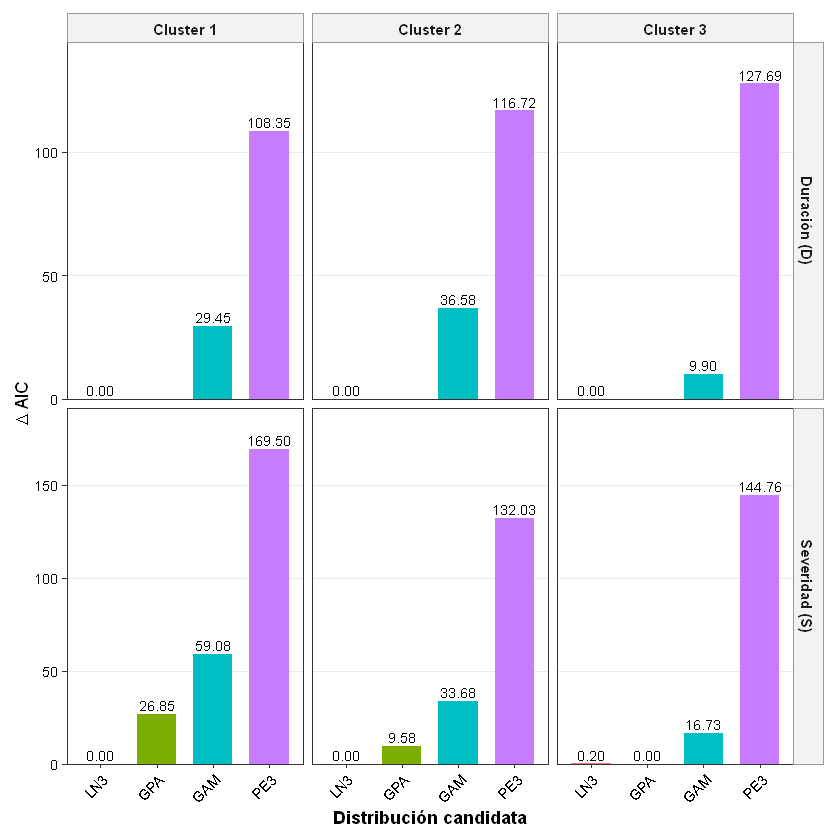

In [11]:
datos_delta_aic <- comparacion_ic %>%
  mutate(
    Grupo = factor(
      Grupo,
      levels = c(
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
      )
    ),
    Variable = factor(
      Variable,
      levels = c(
        "Duración (D)",
        "Severidad (S)"
      )
    ),
    Modelo = factor(
      Modelo,
      levels = c(
        "LN3",
        "GPA",
        "GAM",
        "PE3",
        "WEI"
      )
    )
  )

p_delta_aic <- ggplot(
  datos_delta_aic,
  aes(
    x = Modelo,
    y = Delta_AIC,
    fill = Modelo
  )
) +

  geom_col(
    width = 0.70,
    show.legend = FALSE
  ) +

  geom_text(
    aes(
      label = sprintf(
        "%.2f",
        Delta_AIC
      )
    ),
    vjust = -0.35,
    size = 3.0
  ) +

  facet_grid(
    rows = vars(Variable),
    cols = vars(Grupo),
    scales = "free_y"
  ) +

  scale_y_continuous(
    expand = expansion(
      mult = c(
        0,
        0.13
      )
    )
  ) +

  labs(
    x = "Distribución candidata",
    y = expression(Delta~AIC)
  ) +

  theme_bw(
    base_size = 11
  ) +

  theme(
    strip.background = element_rect(
      fill = "grey95",
      colour = "grey60",
      linewidth = 0.35
    ),
    strip.text = element_text(
      face = "bold",
      size = 9
    ),
    axis.title = element_text(
      face = "bold"
    ),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      colour = "black",
      size = 8.5
    ),
    axis.text.y = element_text(
      colour = "black",
      size = 8.5
    ),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    plot.margin = margin(
      8,
      10,
      8,
      8
    )
  )

print(
  p_delta_aic
)

archivos_fig_delta_aic <- guardar_figura(
  plot = p_delta_aic,
  nombre_base = "delta_aic_marginales_nspei3",
  ruta = ruta_figuras,
  width = 10.8,
  height = 7.0,
  dpi = 600
)

## 12. Figura 2 — CDF empírica y CDF ajustada de las marginales seleccionadas


Figura: cdf_empirica_ajustada_marginales_nspei3
PNG : OK
PDF : OK


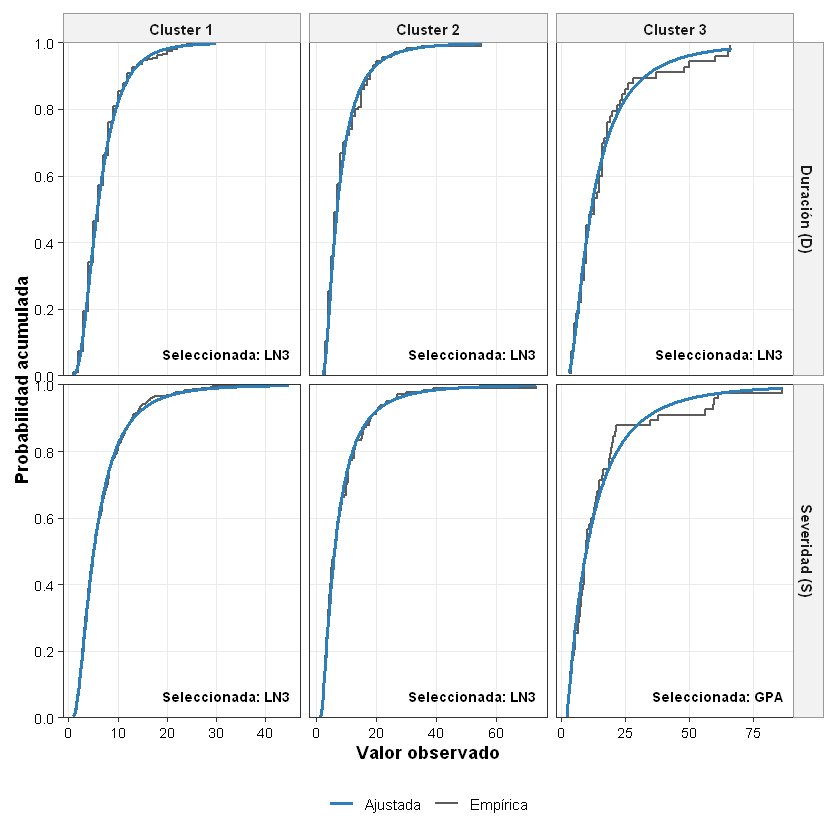

In [12]:
anotaciones_modelo <- mejores_marginales %>%
  transmute(
    Grupo,
    Variable,
    etiqueta = paste0(
      "Seleccionada: ",
      Modelo
    )
  )

p_cdf <- ggplot() +

  geom_step(
    data = df_cdf_emp,
    aes(
      x = x,
      y = prob,
      colour = "Empírica"
    ),
    linewidth = 0.65,
    alpha = 0.85
  ) +

  geom_line(
    data = df_cdf_fit,
    aes(
      x = x,
      y = prob,
      colour = "Ajustada"
    ),
    linewidth = 0.95
  ) +

  geom_text(
    data = anotaciones_modelo,
    aes(
      x = Inf,
      y = 0.05,
      label = etiqueta
    ),
    hjust = 1.08,
    vjust = 0,
    size = 3.0,
    fontface = "bold",
    inherit.aes = FALSE
  ) +

  facet_grid(
    rows = vars(Variable),
    cols = vars(Grupo),
    scales = "free_x"
  ) +

  scale_colour_manual(
    values = c(
      "Empírica" = "grey25",
      "Ajustada" = "#2C7FB8"
    ),
    name = NULL
  ) +

  scale_y_continuous(
    limits = c(
      0,
      1
    ),
    breaks = seq(
      0,
      1,
      0.2
    ),
    expand = c(
      0,
      0
    )
  ) +

  labs(
    x = "Valor observado",
    y = "Probabilidad acumulada"
  ) +

  theme_bw(
    base_size = 11
  ) +

  theme(
    strip.background = element_rect(
      fill = "grey95",
      colour = "grey60",
      linewidth = 0.35
    ),
    strip.text = element_text(
      face = "bold",
      size = 9
    ),
    axis.title = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black",
      size = 8.5
    ),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(
      size = 9
    ),
    plot.margin = margin(
      8,
      10,
      8,
      8
    )
  )

print(
  p_cdf
)

archivos_fig_cdf <- guardar_figura(
  plot = p_cdf,
  nombre_base = "cdf_empirica_ajustada_marginales_nspei3",
  ruta = ruta_figuras,
  width = 11.0,
  height = 7.2,
  dpi = 600
)

## 13. Figura 3 — diagnóstico Q-Q de las marginales seleccionadas


Figura: qq_marginales_seleccionadas_nspei3
PNG : OK
PDF : OK


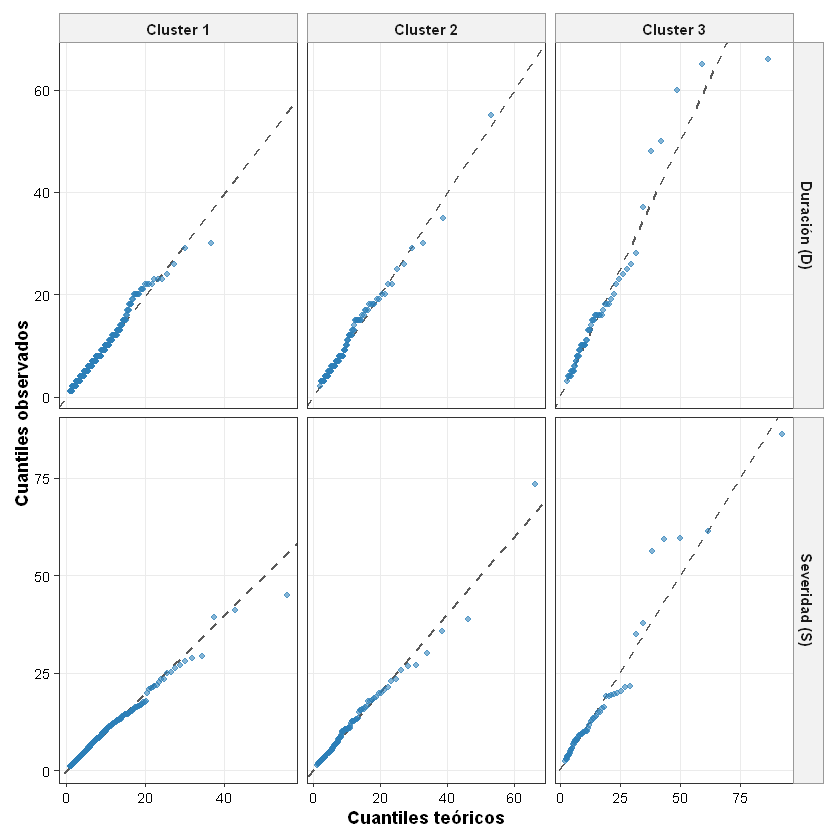

In [13]:
datos_qq <- list()
id <- 1

for (i in seq_len(nrow(mejores_marginales))) {

  fila <- mejores_marginales[i, ]

  x <- obtener_muestra(
    fila$Grupo,
    fila$Variable
  )

  x <- sort(
    x[is.finite(x)]
  )

  n <- length(x)

  p <- (
    seq_len(n) - 0.5
  ) / n

  modelo <- fila$Modelo
  tipo <- tolower(modelo)

  par_obj <- crear_par_obj(
    modelo,
    fila$Parametros
  )

  q_teorico <- qua_lmomco(
    p,
    tipo,
    par_obj
  )

  datos_qq[[id]] <- tibble(
    Grupo = fila$Grupo,
    Variable = fila$Variable,
    Modelo = modelo,
    cuantiles_teoricos = q_teorico,
    cuantiles_observados = x
  )

  id <- id + 1
}

df_qq <- bind_rows(
  datos_qq
) %>%
  filter(
    is.finite(cuantiles_teoricos),
    is.finite(cuantiles_observados)
  )

p_qq <- ggplot(
  df_qq,
  aes(
    x = cuantiles_teoricos,
    y = cuantiles_observados
  )
) +

  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed",
    linewidth = 0.65,
    colour = "grey35"
  ) +

  geom_point(
    alpha = 0.58,
    size = 1.35,
    colour = "#2C7FB8"
  ) +

  facet_grid(
    rows = vars(Variable),
    cols = vars(Grupo),
    scales = "free"
  ) +

  labs(
    x = "Cuantiles teóricos",
    y = "Cuantiles observados"
  ) +

  theme_bw(
    base_size = 11
  ) +

  theme(
    strip.background = element_rect(
      fill = "grey95",
      colour = "grey60",
      linewidth = 0.35
    ),
    strip.text = element_text(
      face = "bold",
      size = 9
    ),
    axis.title = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black",
      size = 8.5
    ),
    panel.grid.minor = element_blank(),
    plot.margin = margin(
      8,
      10,
      8,
      8
    )
  )

print(
  p_qq
)

archivos_fig_qq <- guardar_figura(
  plot = p_qq,
  nombre_base = "qq_marginales_seleccionadas_nspei3",
  ruta = ruta_figuras,
  width = 11.0,
  height = 7.2,
  dpi = 600
)

## 14. Cuantiles de referencia de las marginales seleccionadas

In [14]:
probabilidades_ref <- c(
  0.50,
  0.75,
  0.90,
  0.95
)

tabla_cuantiles <- list()
id <- 1

for (i in seq_len(nrow(mejores_marginales))) {

  fila <- mejores_marginales[i, ]

  par_obj <- crear_par_obj(
    fila$Modelo,
    fila$Parametros
  )

  q <- qua_lmomco(
    probabilidades_ref,
    tolower(fila$Modelo),
    par_obj
  )

  tabla_cuantiles[[id]] <- tibble(
    Grupo = fila$Grupo,
    Variable = fila$Variable,
    Modelo = fila$Modelo,
    q50 = q[1],
    q75 = q[2],
    q90 = q[3],
    q95 = q[4]
  )

  id <- id + 1
}

tabla_15 <- bind_rows(
  tabla_cuantiles
)

cat(
  "\nCUANTILES DE REFERENCIA:\n"
)

mostrar_tabla(
  tabla_15,
  n = Inf
)

readr::write_csv(
  tabla_15,
  file.path(
    ruta_tablas,
    "tabla_15_cuantiles_marginales_seleccionadas_nspei3.csv"
  )
)


CUANTILES DE REFERENCIA:
# A tibble: 6 × 7
  Grupo     Variable      Modelo   q50   q75   q90   q95
  <chr>     <chr>         <chr>  <dbl> <dbl> <dbl> <dbl>
1 Cluster 1 Duración (D)  LN3     5.80  8.66  12.4  15.3
2 Cluster 1 Severidad (S) LN3     5.06  8.32  13.2  17.4
3 Cluster 2 Duración (D)  LN3     6.82 10.8   16.9  22.4
4 Cluster 2 Severidad (S) LN3     5.98 10.4   17.8  24.6
5 Cluster 3 Duración (D)  LN3    11.7  19.8   32.9  44.8
6 Cluster 3 Severidad (S) GPA     9.75 18.6   32.9  46.0


## 15. Controles contra los resultados definitivos documentados

In [15]:
esperado <- tribble(
  ~Grupo,      ~Variable,       ~Modelo,
  "Cluster 1", "Duración (D)",  "LN3",
  "Cluster 1", "Severidad (S)", "LN3",
  "Cluster 2", "Duración (D)",  "LN3",
  "Cluster 2", "Severidad (S)", "LN3",
  "Cluster 3", "Duración (D)",  "LN3",
  "Cluster 3", "Severidad (S)", "GPA"
)

control_modelos <- mejores_marginales %>%
  select(
    Grupo,
    Variable,
    Modelo
  ) %>%
  left_join(
    esperado %>%
      rename(
        Modelo_esperado = Modelo
      ),
    by = c(
      "Grupo",
      "Variable"
    )
  ) %>%
  mutate(
    coincide =
      Modelo == Modelo_esperado
  )

cat(
  "\nCONTROL DE MODELOS SELECCIONADOS:\n"
)

mostrar_tabla(
  control_modelos,
  n = Inf
)

if (any(!control_modelos$coincide)) {
  warning(
    "ATENCIÓN: una o más marginales seleccionadas ",
    "difieren de los resultados definitivos documentados."
  )
}

delta_c3 <- control_c3_sev %>%
  arrange(AIC) %>%
  summarise(
    Delta_AIC_GPA_LN3 =
      diff(sort(AIC))[1],
    Delta_BIC_GPA_LN3 =
      diff(sort(BIC))[1]
  )

cat(
  "\nCONTROL DEL CASI EMPATE EN CLUSTER 3 - SEVERIDAD:\n"
)

mostrar_tabla(
  delta_c3,
  n = Inf
)


CONTROL DE MODELOS SELECCIONADOS:
# A tibble: 6 × 5
  Grupo     Variable      Modelo Modelo_esperado coincide
  <chr>     <chr>         <chr>  <chr>           <lgl>   
1 Cluster 1 Duración (D)  LN3    LN3             TRUE    
2 Cluster 1 Severidad (S) LN3    LN3             TRUE    
3 Cluster 2 Duración (D)  LN3    LN3             TRUE    
4 Cluster 2 Severidad (S) LN3    LN3             TRUE    
5 Cluster 3 Duración (D)  LN3    LN3             TRUE    
6 Cluster 3 Severidad (S) GPA    GPA             TRUE    

CONTROL DEL CASI EMPATE EN CLUSTER 3 - SEVERIDAD:
# A tibble: 1 × 2
  Delta_AIC_GPA_LN3 Delta_BIC_GPA_LN3
              <dbl>             <dbl>
1             0.202             0.202


## 16. Manifiesto, `sessionInfo()` y cierre reproducible

In [16]:
archivo_session <- file.path(
  ruta_reproducibilidad,
  "sessionInfo_marginales_nspei3.txt"
)

writeLines(
  capture.output(
    sessionInfo()
  ),
  archivo_session
)

archivos_figuras <- c(
  archivos_fig_delta_aic,
  archivos_fig_cdf,
  archivos_fig_qq
)

archivos_extra <- c(
  file.path(
    ruta_tablas,
    "tabla_14_diagnostico_cdf_marginales_nspei3.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_15_cuantiles_marginales_seleccionadas_nspei3.csv"
  ),
  archivo_session
)

archivos_manifiesto <- unique(
  c(
    archivos_tablas,
    archivos_figuras,
    archivos_extra
  )
)

# Eliminar NA provenientes de un PDF que eventualmente no se pudiera guardar.
archivos_manifiesto <- archivos_manifiesto[
  !is.na(archivos_manifiesto)
]

manifiesto <- tibble(
  archivo = archivos_manifiesto
) %>%
  mutate(
    tipo = case_when(
      grepl("\\.(png|pdf)$", archivo, ignore.case = TRUE) ~ "figura",
      grepl("sessionInfo", archivo, ignore.case = TRUE) ~ "reproducibilidad",
      TRUE ~ "tabla"
    ),
    existe = file.exists(archivo),
    tamano_bytes = ifelse(
      existe,
      file.info(archivo)$size,
      NA_real_
    )
  )

archivo_manifiesto <- file.path(
  ruta_reproducibilidad,
  "manifiesto_marginales_nspei3.csv"
)

readr::write_csv(
  manifiesto,
  archivo_manifiesto
)

cat(
  "\n============================================================\n",
  "CONTROL FINAL DEL MÓDULO 03\n",
  "============================================================\n"
)

mostrar_tabla(
  manifiesto,
  n = Inf
)

if (any(!manifiesto$existe)) {
  warning(
    "ATENCIÓN: uno o más productos esperados no fueron generados."
  )
}

cat(
  "\nMarginales finales:\n"
)

mostrar_tabla(
  mejores_marginales %>%
    select(
      Grupo,
      Variable,
      Modelo,
      n,
      AIC,
      BIC,
      Parametros,
      Coincide_AIC_BIC
    ),
  n = Inf
)

cat(
  "\nTablas  : ", ruta_tablas,
  "\nFiguras : ", ruta_figuras,
  "\nManifiesto: ", archivo_manifiesto,
  "\n",
  sep = ""
)

cat(
  "\n============================================================\n",
  "MÓDULO 03 COMPLETADO\n",
  "Momentos-L = inicialización | Parámetros finales = MLE\n",
  "============================================================\n"
)


 CONTROL FINAL DEL MÓDULO 03
# A tibble: 17 × 4
   archivo                                                                                                                           tipo             existe tamano_bytes
   <chr>                                                                                                                             <chr>            <lgl>         <dbl>
 1 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/tablas/ajuste_marginales_nspei3_por_cluster.csv               tabla            TRUE           4952
 2 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/tablas/mejores_marginales_nspei3_por_cluster.csv              tabla            TRUE           1637
 3 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/tablas/tabla_10_mejores_marginales_nspei3.csv                 tabla            TRUE           1033
 4 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/03_marginales/tablas/tabla_11_marginales_dur